# **Homework 6: BBVI for non-conjugate models**
STAT 348, UChicago, Spring 2026

----------------
**Your name here:** Rodrigo Paz

**Hours spent:** 8

(Please let us know how many hours in total you spent on this assignment so we can calibrate for future assignments. Your feedback is always welcome!)

----------------

<a href="https://colab.research.google.com/github/aschein/stat_348_2026/blob/main/assignments/hw6/hw6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

## Instructions

This homework focuses on **black-box variational inference (BBVI)** for approximate posterior inference in non-conjugate models.

BBVI is a Monte Carlo–based variational inference algorithm built on the **score-function gradient (or REINFORCE) estimator**. This homework will also have you implement the two main strategies for combatting gradient variance with BBVI: **1) Rao-Blackwellization** and **2) control variates**.

Assignment is due **Sunday May 27, 11:59pm** on GradeScope.

## Data

We have data about $N$ musical artists coming from two different modalities: 1) listener preference data and 2) genre tag descriptions.

**Pairwise listener preferences.** A polling firm has asked listeners a series of pairwise comparisons of the form: "_Would you rather listen to artist $i$ or artist $j$?_'' For each unordered pair of artists $(i, j)$, we observe the count $w_{i,j} \in \mathbb{N}$ of listeners who preferred $i$ over $j$ out of the total $n_{i,j}$ who answered.

**Tag counts.** For a vocabulary of $V$ tags drawn from a last.fm-style folksonomy (`pop`, `electronic`, `noise`, `love`, `metal`, ...), $y_{i, v} \in \mathbb{N}$ is then the number of times tag $v$ has been applied to describe artist $i$'s songs.

## Goal

For each artist, our goal is to use the data above to infer a one-dimensional latent variable $x_i \in \mathbb{R}$ that represents how "pop"/"mainstream" versus "niche" an artist is.

Intuitively, artists that are preferred by a larger proportion of listeners can be said to be more "pop". However, we also believe that the tag data offers a strong signal about which artists are more/less "pop", and this may be useful in cases where the preference data is too scarce.

We will build and fit a joint model in which the single one-dimensional latent feature $x_i$ explains both data sources at once.

## Model

For $i = 1, \ldots, N$ artists, we assume the following binomial model for the user preference data:
$$w_{i, j} \sim \mathrm{Bin}\!\big(n_{i, j},\; \sigma(x_i - x_j)\big)$$
where $\sigma(x) = (1 + e^{-x})^{-1}$ is the sigmoid function. This draws upon the classic [Bradley-Terry model](https://en.wikipedia.org/wiki/Bradley%E2%80%93Terry_model) for pairwise preferences or win-loss data. The equation above is consistent with the following assumption:

$$\textrm{logit} \, P(i \textrm{ is preferred to } j) = x_i - x_j$$

where again $x_i \in \mathbb{R}$ represents how "pop" versus "niche" an artist is.

For each artist $i$ and each unique last.fm tag $v \in \{1 \dots V\}$ we then assume:
$$y_{i, v} \sim \mathrm{Po}\!\big(\exp(c + x_i\, \eta_v)\big)$$
where $c \in \mathbb{R}$ is some baseline and $\eta_v \in \mathbb{R}$ represents how "pop" a certain tag $v$ is. If both $x_i$ and $\eta_v$ have large absolute value and both have the same sign (e.g., both artist $i$ and tag $v$ are "pop" or both are "niche"), then $y_{i,v}$ will be large. This part of the model is inspired by "ideal point models" in political science (for an approachable background on that see [Vafa et al. (2020)](https://arxiv.org/pdf/2005.04232)).

Note that while the Poisson likelihood is invariant under simultaneous sign flip (i.e., $x_i \to -x_i$ and $\eta_v \to -\eta_v$) the binomial/Bradley-Terry (BT) likelihood is not. Thus, the BT portion of the model ensures that **we can interpret $x_i > 0$ as meaning "more pop" and $x_i < 0$ as meaning "less pop"**.

Finally, assume the following simple priors:
$$
\begin{align*}
x_i  &\sim \mathcal{N}(0, 1) &\textrm{and}\,\,\, \eta_v   &\sim \mathcal{N}(0, 1) \\
\end{align*}
$$
Denote $\boldsymbol{x} \equiv (x_1,\dots,x_N)$ and  $\boldsymbol{\eta} \equiv (\eta_1,\dots,\eta_V)$.



## Variational inference setup

We will approximate the posterior $p(\boldsymbol{x}, \boldsymbol{\eta} \mid \mathrm{data})$ with a fully-factorized Gaussian:
$$
q_{\boldsymbol{\lambda}}(\boldsymbol{x}, \boldsymbol{\eta})
\;=\; \prod_{i=1}^N \mathcal{N}\!\big(x_i \mid \, \mu^{(x)}_i,\, \exp(2\gamma^{(x)}_i)\big)
       \prod_{v=1}^V \mathcal{N}\!\big(\eta_v \mid \, \mu^{(\eta)}_v,\,\exp(2{\gamma^{(\eta)}_v})\big),
$$
parameterized by **variational parameters** $\boldsymbol{\lambda} \equiv \{\boldsymbol{\mu}^{(x)}, \boldsymbol{\gamma}^{(x)}, \boldsymbol{\mu}^{(\eta)}, \boldsymbol{\gamma}^{(\eta)}\}$ where we are parameterizing the variances (e.g., $\exp(2\gamma^{(x)}_i)$) in terms of the log standard deviation ($\gamma_i^{(x)} \in \mathbb{R}$) which is unconstrained and thus amenable to simple gradient-based optimization.

We will seek to fit the variational parameters $\boldsymbol{\lambda}$ via gradient ascent on the ELBO:

$$\boldsymbol{\lambda}_t \leftarrow \boldsymbol{\lambda}_{t-1} + \rho_t \nabla_{\boldsymbol{\lambda}} \mathcal{L}(\boldsymbol{\lambda})$$

where the ELBO is define as:
$$
\mathcal{L}(\boldsymbol{\lambda})
\;=\; \mathbb{E}_{q_{\boldsymbol{\lambda}}}\!\left[\, \log p(\boldsymbol{x}, \boldsymbol{\eta}, \mathrm{data})
                                             \;-\; \log q_{\boldsymbol{\lambda}}(\boldsymbol{x}, \boldsymbol{\eta}) \,\right].
$$

## Setup

In [1]:
import math
import torch
import torch.nn.functional as F
from torch.distributions import Binomial, Poisson, Normal

from tqdm.auto import trange

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("notebook")

## Load the data

The file `data.pt` is a Python dictionary containing the pairwise polling data, the tag-count matrix, the artist names, and the tag vocabulary, along with the constant log-rate offset $c$. (It also contains the latent values $x_i$ and $\eta_v$ used to construct the dataset, which we will use for verification later.)

We will pass this `data` dictionary directly into our inference functions below; for the data-exploration cells we also unpack a few of its entries into convenience names.

In [2]:
%%capture
!wget https://github.com/aschein/stat_348_2026/raw/main/assignments/hw6/data.pt

In [3]:
data = torch.load("data.pt", weights_only=False)

artists    = data["artists"]                # list of N artist names
tags       = data["tags"]                   # list of V tag names
Y_NV       = data["Y_NV"]                   # (N, V) tag counts
W_NN       = data["W_NN"]                   # (N, N) preference counts: W[i, j] = # who prefer i over j
x_true_N   = data["x_true_N"]               # (N,) -- for verification
eta_true_V = data["eta_true_V"]             # (V,) -- for verification

N, V = Y_NV.shape
print(f"N artists  : {N}")
print(f"V tags     : {V}")

N artists  : 30
V tags     : 53


### Get a feel for the data

In [4]:
# The artists.
print(artists)

['Sunn O)))', 'Cattle Decapitation', 'Sleep', 'Death Grips', 'Slayer', 'Tool', 'Aphex Twin', 'Animal Collective', 'Boards of Canada', 'Mitski', 'Bon Iver', 'Phoebe Bridgers', 'The National', 'Vampire Weekend', 'The Strokes', 'Arctic Monkeys', 'Tyler the Creator', 'Lana Del Rey', 'Kendrick Lamar', 'Lorde', 'Imagine Dragons', 'Maroon 5', 'Coldplay', 'Billie Eilish', 'The Weeknd', 'Drake', 'Ed Sheeran', 'Beyoncé', 'Ariana Grande', 'Taylor Swift']


In [5]:
# The tags.
print(tags)

['pop', 'mainstream', 'top 40', 'chart', 'hit', 'radio', 'catchy', 'happy', 'love', 'dance', 'party', 'summer', 'romantic', 'dance pop', 'guilty pleasure', 'rnb', 'hip hop', 'rap', 'vocal', 'rock', 'guitar', 'alternative', 'indie', 'indie rock', 'electronic', 'acoustic', 'folk', 'singer-songwriter', 'melancholy', 'moody', 'atmospheric', 'introspective', 'dark', 'post-rock', 'shoegaze', 'dream pop', 'ambient', 'idm', 'minimalist', 'metal', 'death metal', 'black metal', 'doom', 'grindcore', 'noise', 'harsh', 'experimental', 'avant-garde', 'drone', 'classical', 'jazz', 'baroque', 'piano']


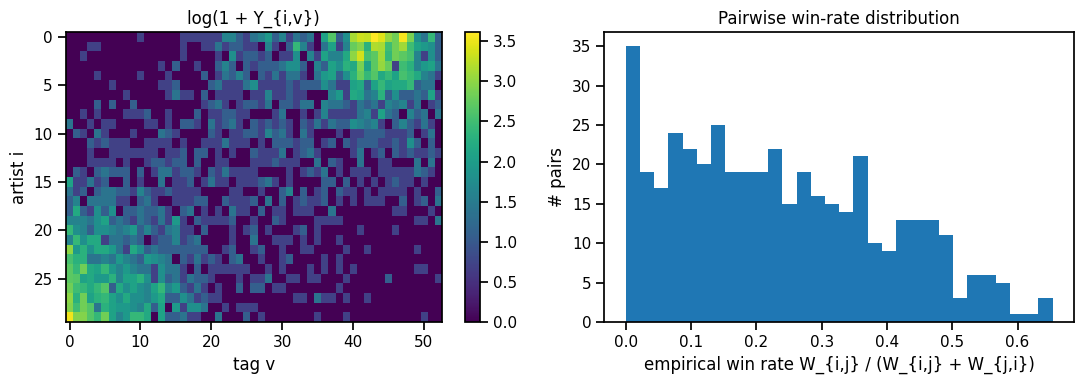

In [6]:
# Distribution of tag counts (log scale, for visibility) and pairwise win rates.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].imshow(torch.log1p(Y_NV).numpy(), aspect="auto", cmap="viridis")
axes[0].set_xlabel("tag v"); axes[0].set_ylabel("artist i")
axes[0].set_title("log(1 + Y_{i,v})")
plt.colorbar(im, ax=axes[0])

iu, ju = torch.triu_indices(N, N, offset=1)
win_rates = W_NN[iu, ju] / (W_NN[iu, ju] + W_NN[ju, iu])
axes[1].hist(win_rates.numpy(), bins=30)
axes[1].set_xlabel("empirical win rate W_{i,j} / (W_{i,j} + W_{j,i})")
axes[1].set_ylabel("# pairs")
axes[1].set_title("Pairwise win-rate distribution")
plt.tight_layout()
plt.show()

In [7]:
# Top tags for a few artists, for sanity.
def top_tags_for(artist_name, k=5):
    i = artists.index(artist_name)
    order = torch.argsort(Y_NV[i], descending=True)
    return [(tags[j.item()], int(Y_NV[i, j].item())) for j in order[:k]]

for a in [artists[0], artists[N // 2], artists[-1]]:
    print(f"{a:25s}  top tags: {top_tags_for(a)}")

Sunn O)))                  top tags: [('grindcore', 36), ('avant-garde', 34), ('noise', 30), ('black metal', 27), ('doom', 26)]
Arctic Monkeys             top tags: [('pop', 7), ('chart', 3), ('guitar', 3), ('melancholy', 3), ('dance pop', 3)]
Taylor Swift               top tags: [('pop', 33), ('mainstream', 18), ('top 40', 18), ('radio', 16), ('chart', 13)]


## Problem 1: The BBVI gradient [math, code]

### Problem 1a: Score-function identity

Let $q_{\boldsymbol{\lambda}}(z)$ be a parametric density and let $f$ be any function. Show, under regularity conditions allowing the interchange of integral and derivative, that
$$
\nabla_{\boldsymbol{\lambda}}\, \mathbb{E}_{z \sim q_{\boldsymbol{\lambda}}}\!\big[f(z)\big]
\;=\; \mathbb{E}_{z \sim q_{\boldsymbol{\lambda}}}\!\big[ f(z) \,\nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}(z) \big].
$$

---

We expand the gradient by moving it inside the integral (justified by the regularity conditions):

$$\nabla_{\boldsymbol{\lambda}}\, \mathbb{E}_{z \sim q_{\boldsymbol{\lambda}}}\!\big[f(z)\big] = \nabla_{\boldsymbol{\lambda}} \int f(z)\, q_{\boldsymbol{\lambda}}(z)\, dz = \int f(z)\, \nabla_{\boldsymbol{\lambda}}\, q_{\boldsymbol{\lambda}}(z)\, dz$$

Apply the log-derivative trick, $\nabla_{\boldsymbol{\lambda}}\, q_{\boldsymbol{\lambda}}(z) = q_{\boldsymbol{\lambda}}(z)\, \nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}(z)$:

$$= \int f(z)\, q_{\boldsymbol{\lambda}}(z)\, \nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}(z)\, dz$$

Recognizing this as an expectation under $q_{\boldsymbol{\lambda}}$:

$$= \mathbb{E}_{z \sim q_{\boldsymbol{\lambda}}}\!\big[ f(z)\, \nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}(z) \big]$$

---

### Problem 1b: ELBO gradient

Consider the Monte Carlo estimator of $\nabla_{\boldsymbol{\lambda}}\, \mathcal{L}(\boldsymbol{\lambda})$ that depends only on samples $\boldsymbol{z}^{(s)} \equiv (\boldsymbol{x}^{(s)}, \boldsymbol{\eta}^{(s)}) \stackrel{\text{iid}}{\sim} q_{\boldsymbol{\lambda}}$.
$$
\widehat{\nabla}_{\boldsymbol{\lambda}}\, \mathcal{L}(\boldsymbol{\lambda})
\;=\; \frac{1}{S} \sum_{s=1}^S g(\boldsymbol{z}^{(s)}, \boldsymbol{\lambda}) \nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}(\boldsymbol{z}^{(s)}),
$$
where the *learning signal* is defined as $g(\boldsymbol{z}, \boldsymbol{\lambda}) \equiv \log p(\boldsymbol{z}, \mathrm{data}) - \log q_{\boldsymbol{\lambda}}(\boldsymbol{z}^{(s)})$. Show that the estimator above is unbiased.


---

Write the ELBO gradient in integral form by applying 1a with $f(\boldsymbol{z}) = \log p(\boldsymbol{z}, \mathrm{data}) - \log q_{\boldsymbol{\lambda}}(\boldsymbol{z})$:

$$\nabla_{\boldsymbol{\lambda}}\, \mathcal{L}(\boldsymbol{\lambda}) = \mathbb{E}_{q_{\boldsymbol{\lambda}}}\!\left[\big(\log p(\boldsymbol{z}, \mathrm{data}) - \log q_{\boldsymbol{\lambda}}(\boldsymbol{z})\big)\, \nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}(\boldsymbol{z}) \right]$$

The estimator $\widehat{\nabla}_{\boldsymbol{\lambda}}\, \mathcal{L}(\boldsymbol{\lambda})$ is an average of iid terms, each drawn from $q_{\boldsymbol{\lambda}}$, so by linearity of expectation:

$$\mathbb{E}\!\left[\widehat{\nabla}_{\boldsymbol{\lambda}}\, \mathcal{L}(\boldsymbol{\lambda})\right] = \frac{1}{S}\sum_{s=1}^S \mathbb{E}_{q_{\boldsymbol{\lambda}}}\!\left[g(\boldsymbol{z}^{(s)}, \boldsymbol{\lambda})\, \nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}(\boldsymbol{z}^{(s)})\right]$$

Each term in the sum is identical (same distribution, same function), so:

$$= \mathbb{E}_{q_{\boldsymbol{\lambda}}}\!\left[g(\boldsymbol{z}, \boldsymbol{\lambda})\, \nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}(\boldsymbol{z})\right] = \nabla_{\boldsymbol{\lambda}}\, \mathcal{L}(\boldsymbol{\lambda})$$

---

### Problem 1c: Score for a Gaussian factor

For $q(z \mid \mu, \gamma) = \mathcal{N}(\mu,\, \exp(2\gamma))$, derive closed-form expressions for $\partial_\mu \log q(z; \mu, \gamma)$ and $\partial_\gamma \log q(z; \mu, \gamma)$. Verify directly that each has zero expectation under $q$.

---

Write the log-density of $q(z \mid \mu, \gamma) = \mathcal{N}(\mu,\, \exp(2\gamma))$. With $\sigma^2 = \exp(2\gamma)$:

$$\log q(z; \mu, \gamma) = -\frac{1}{2}\log(2\pi) - \gamma - \frac{(z - \mu)^2}{2\exp(2\gamma)}$$

**Score w.r.t. $\mu$:**

$$\partial_\mu \log q = \frac{z - \mu}{\exp(2\gamma)}$$

Taking the expectation under $q$, where $\mathbb{E}_q[z - \mu] = 0$:

$$\mathbb{E}_q\!\left[\partial_\mu \log q\right] = \frac{\mathbb{E}_q[z - \mu]}{\exp(2\gamma)} = 0 \qquad \checkmark$$

**Score w.r.t. $\gamma$:**

Differentiating the log-density with respect to $\gamma$:

$$\partial_\gamma \log q = -1 + \frac{(z - \mu)^2}{\exp(2\gamma)}$$

Taking the expectation under $q$, where $\mathbb{E}_q[(z-\mu)^2] = \exp(2\gamma)$:

$$\mathbb{E}_q\!\left[\partial_\gamma \log q\right] = -1 + \frac{\exp(2\gamma)}{\exp(2\gamma)} = 0 \qquad \checkmark$$

---

### Problem 1d: Implement `bbvi_step`

Implement BBVI as three small functions. We will pass three dictionaries throughout: the `data` dict that you already loaded, a `latents` dict with the sampled latents (e.g., `latents["x_N"]` of shape $(S, N)$ and `latents["eta_V"]` of shape $(S, V)$), and a `var_params` dict holding the four variational parameter tensors `mu_x_N`, `gamma_x_N`, `mu_eta_V`, `gamma_eta_V`.

1. `gaussian_score(z, mu, gamma)` — for a Gaussian factor $\mathcal{N}(\mu,\, \exp(2\gamma))$, return the pair $(\partial_\mu \log q,\, \partial_\gamma \log q)$ at $z$.
2. `learning_signal(data, latents, var_params)` — return $g(\boldsymbol{z}^{(s)}, \boldsymbol{\lambda})$ at each of the $S$ samples in `latents`.
3. `bbvi_step(data, var_params, opts, S=20)` — sample $S$ joint draws from $q_{\boldsymbol{\lambda}}$, evaluate the learning signal and the score, average, and take one Adam step on each variational parameter.

In [8]:
def gaussian_score(z, mu, gamma):
    """Compute the score function of a Gaussian q(z; mu, exp(2*gamma)).

        (d log q / d mu, d log q / d gamma) evaluated at z

    Input:
        z, mu, gamma : torch tensors of broadcasting-compatible shapes.

    Return:
        a tuple (score_mu, score_gamma) of tensors with the shape of z.
    """
    score_mu    = (z - mu) / torch.exp(2 * gamma)
    score_gamma = -1 + (z - mu)**2 / torch.exp(2 * gamma)
    return score_mu, score_gamma


def learning_signal(data, latents, var_params):
    """Compute the learning signal

        g(z, lambda) = log p(z, data) - log q_lambda(z)

    at each of S Monte Carlo samples.

    Input:
        data       : data dict (uses 'Y_NV', 'W_NN', 'log_rate_offset').
        latents    : dict with 'x_N' of shape (S, N) and 'eta_V' of shape (S, V).
        var_params : dict with 'mu_x_N', 'gamma_x_N', 'mu_eta_V', 'gamma_eta_V'.

    Return:
        g_S : tensor of shape (S,).
    """
    Y_NV, W_NN = data['Y_NV'], data['W_NN']
    x_N, eta_V = latents['x_N'], latents['eta_V']
    mu_x_N, mu_eta_V       = var_params['mu_x_N'],    var_params['mu_eta_V']
    gamma_x_N, gamma_eta_V = var_params['gamma_x_N'], var_params['gamma_eta_V']

    c   = data['log_rate_offset']
    S   = x_N.shape[0]

    # log p(z): priors
    log_prior = (Normal(0., 1.).log_prob(x_N).sum(-1)
               + Normal(0., 1.).log_prob(eta_V).sum(-1))

    # log p(data | z): Binomial (Bradley-Terry) likelihood
    diff_SNN = x_N.unsqueeze(2) - x_N.unsqueeze(1)
    n_NN     = W_NN + W_NN.t()
    log_lik_bt = Binomial(total_count=n_NN,
                          logits=diff_SNN).log_prob(W_NN).sum((-2, -1))

    # log p(data | z): Poisson (tag) likelihood
    log_rate_SNV = (c + x_N.unsqueeze(2) * eta_V.unsqueeze(1)).clamp(-10, 10)
    log_lik_po   = Poisson(torch.exp(log_rate_SNV)).log_prob(Y_NV).sum((-2, -1))

    log_p = log_prior + log_lik_bt + log_lik_po

    # log q(z): variational distribution
    log_q = (Normal(mu_x_N,  torch.exp(gamma_x_N )).log_prob(x_N ).sum(-1)
           + Normal(mu_eta_V, torch.exp(gamma_eta_V)).log_prob(eta_V).sum(-1))

    return log_p - log_q


def bbvi_step(data, var_params, optimizer, S=20):
    """Take one BBVI step.

        Sample S draws from q_lambda, evaluate the learning signal and the
        score at each sample, average to estimate each parameter's gradient,
        and then call optimizer.step(var_params, grads) to take a gradient
        step on the parameters in-place.

    Input:
        data       : the data dict.
        var_params : dict of variational parameter tensors. Mutated in place.
        optimizer  : a gradient optimizer (e.g., Adam) with optimizer.step(var_params, grads).
        S          : number of Monte Carlo samples.

    Return:
        (scalar) the mean learning signal across the S samples (for monitoring).
    """
    mu_x_N, mu_eta_V       = var_params['mu_x_N'],    var_params['mu_eta_V']
    gamma_x_N, gamma_eta_V = var_params['gamma_x_N'], var_params['gamma_eta_V']

    # sample from q
    x_N   = Normal(mu_x_N,   torch.exp(gamma_x_N )).rsample((S,))
    eta_V = Normal(mu_eta_V, torch.exp(gamma_eta_V)).rsample((S,))
    latents = {'x_N': x_N, 'eta_V': eta_V}

    # learning signal: (S,)
    g_S = learning_signal(data, latents, var_params)

    # scores
    sm_x,  sg_x  = gaussian_score(x_N,   mu_x_N,   gamma_x_N )
    sm_eta, sg_eta = gaussian_score(eta_V, mu_eta_V, gamma_eta_V)

    # gradients: average g * score over S
    g_S_col = g_S.unsqueeze(1)
    grads = {
        'mu_x_N':      (g_S_col * sm_x ).mean(0),
        'gamma_x_N':   (g_S_col * sg_x ).mean(0),
        'mu_eta_V':    (g_S_col * sm_eta).mean(0),
        'gamma_eta_V': (g_S_col * sg_eta).mean(0),  }

    optimizer.step(var_params, grads)
    return g_S.mean().item()

The cell below defines a bare-bones Adam optimizer that maintains running first- and second-moment estimates for each named variational tensor.

To step, call `optimizer.step(var_params, grads)` with a `grads` dict that has the same keys as `var_params`; this mutates `var_params` in place.

The next cell loops `bbvi_step` for many iterations using a single optimizer. We will reuse `fit` later with different step functions, so it takes a `step_fn` argument.

`fit` returns `(var_params, g_trace)`: a dict with the four fitted variational tensors and a 1-D tensor of the per-iteration mean learning signal.

In [9]:
class Adam:
    """Adam optimizer for a dict of named parameter tensors.

        Holds running first- and second-moment estimates per key. Uses lr_mu
        for keys beginning with "mu" and lr_gamma for keys beginning with "gamma".

    Usage:
        optimizer = Adam(lr_mu=0.05, lr_gamma=0.01)
        optimizer.step(var_params, grads)    # var_params is mutated in place
    """
    def __init__(self, lr_mu=0.05, lr_gamma=0.01, betas=(0.9, 0.999), eps=1e-8):
        self.b1, self.b2 = betas
        self.eps = eps
        self.lr_mu, self.lr_gamma = lr_mu, lr_gamma
        self.m, self.v = {}, {}
        self.t = 0

    def step(self, var_params, grads):
        """Take one Adam step. var_params is mutated in place; grads has the same keys."""
        self.t += 1
        for k in var_params:
            if k not in self.m:
                self.m[k] = torch.zeros_like(var_params[k])
                self.v[k] = torch.zeros_like(var_params[k])
            lr = self.lr_mu if k.startswith("mu") else self.lr_gamma
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * grads[k]
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.b1 ** self.t)
            v_hat = self.v[k] / (1 - self.b2 ** self.t)
            var_params[k] += lr * m_hat / (torch.sqrt(v_hat) + self.eps)

In [10]:
def fit(step_fn, data, num_iters=600, S=20, lr_mu=0.05, lr_gamma=0.01, seed=0):
    """Outer BBVI loop; calls step_fn once per iteration."""
    torch.manual_seed(seed)
    N, V = data["Y_NV"].shape

    var_params = {
        "mu_x_N":      0.05 * torch.randn(N),
        "gamma_x_N":   torch.zeros(N),
        "mu_eta_V":    0.05 * torch.randn(V),
        "gamma_eta_V": torch.zeros(V),
    }
    optimizer = Adam(lr_mu=lr_mu, lr_gamma=lr_gamma)

    g_trace = []
    for _ in trange(num_iters):
        g = step_fn(data, var_params, optimizer, S=S)
        g_trace.append(g)

    return var_params, torch.tensor(g_trace)

### Problem 1e: Run inference

Run `fit` with `bbvi_step` and then plot the mean learning signal (returned by each BBVI step) over iteration. What does the plot show? Is the algorithm "working"? Why or why not?

  0%|          | 0/600 [00:00<?, ?it/s]

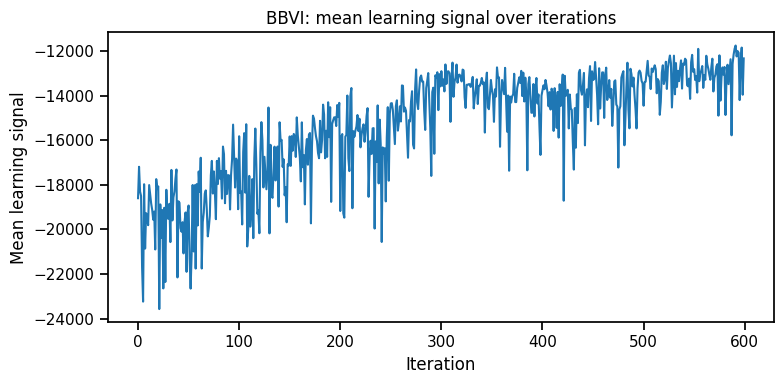

In [11]:
var_params, g_trace = fit(bbvi_step, data, seed=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(g_trace.numpy())
ax.set_xlabel("Iteration")
ax.set_ylabel("Mean learning signal")
ax.set_title("BBVI: mean learning signal over iterations")
plt.tight_layout()
plt.show()

---

Your answer here: *What do you observe?*

The learning signal increases steadily from around −24,000 toward −12,000 over 600 iterations, indicating the ELBO is being maximized and the algorithm is converging in the right direction. However, the trace remains very noisy throughout — this is the expected behavior of vanilla BBVI, where the score-function gradient estimator has inherently high variance with no variance reduction applied. The algorithm is "working" in the sense that the ELBO is improving, but the noisy gradients slow and destabilize convergence compared to what Rao-Blackwellization and control variates will achieve in Problems 2 and 3.

---

## Problem 2: Rao-Blackwellization [math, code]

Recall that our variational distribution factorizes as follows:

$$q_{\boldsymbol{\lambda}}(\mathbf{z}) = \prod_{d=1}^D q_{\boldsymbol{\lambda}_d}(z_d)$$

where each $z_d$ is one latent variable in our model (e.g., $z_d \equiv \eta_v$) and $\boldsymbol{\lambda}_d$ are its variational parameters (e.g., $\boldsymbol{\lambda}_d \equiv \{\mu_v^{(\eta)}, \gamma^{(\eta)}_v\}$).

Now consider the decomposition of the learning signal into a part which depends on $z_d$ and a part which does not:
$$
g(\boldsymbol{z}, \boldsymbol{\lambda}) \;=\; g_d(z_d, \mathbf{z}_{-d}, \boldsymbol{\lambda}) \;+\; g_{-d}(\mathbf{z}_{-d}, \boldsymbol{\lambda}).
$$

We will exploit this form in deriving a lower variance estimator for $\nabla_{\boldsymbol{\lambda}_d} \mathcal{L}(\boldsymbol{\lambda})$.

### Problem 2a: Show that the **Rao-Blackwellized** estimator is unbiased

Show that the following Rao-Blackwellized gradient estimator below is unbiased.
$$
\widehat{\nabla}_{\boldsymbol{\lambda}_d}\, \mathcal{L}^{\,\text{RB}}(\boldsymbol{\lambda})
\;=\; \frac{1}{S}\sum_{s=1}^S g_d\!\big(z_d^{(s)}, z_{-d}^{(s)}, \boldsymbol{\lambda}\big) \cdot \nabla_{\boldsymbol{\lambda}_d} \log q_{\boldsymbol{\lambda}}\!\big(z_d^{(s)}\big)
$$

---

Starting from the full BBVI gradient (shown unbiased in 1b), isolate the gradient with respect to $\boldsymbol{\lambda}_d$. Since $q_{\boldsymbol{\lambda}}$ factorizes, $\nabla_{\boldsymbol{\lambda}_d} \log q_{\boldsymbol{\lambda}}(\boldsymbol{z}) = \nabla_{\boldsymbol{\lambda}_d} \log q_{\boldsymbol{\lambda}_d}(z_d)$, so:

$$\nabla_{\boldsymbol{\lambda}_d}\, \mathcal{L}(\boldsymbol{\lambda}) = \mathbb{E}_{q_{\boldsymbol{\lambda}}}\!\left[ g(\boldsymbol{z}, \boldsymbol{\lambda})\, \nabla_{\boldsymbol{\lambda}_d} \log q_{\boldsymbol{\lambda}_d}(z_d) \right]$$

Substitute the decomposition $g(\boldsymbol{z}, \boldsymbol{\lambda}) = g_d(z_d, \mathbf{z}_{-d}, \boldsymbol{\lambda}) + g_{-d}(\mathbf{z}_{-d}, \boldsymbol{\lambda})$ and split the expectation:

$$= \mathbb{E}_{q_{\boldsymbol{\lambda}}}\!\left[ g_d\, \nabla_{\boldsymbol{\lambda}_d} \log q_{\boldsymbol{\lambda}_d}(z_d) \right] + \mathbb{E}_{q_{\boldsymbol{\lambda}}}\!\left[ g_{-d}\, \nabla_{\boldsymbol{\lambda}_d} \log q_{\boldsymbol{\lambda}_d}(z_d) \right]$$

The second term is zero by the score-function identity (1a) applied to $g_{-d}$, which does not depend on $z_d$:

$$\mathbb{E}_{q_{\boldsymbol{\lambda}}}\!\left[ g_{-d}\, \nabla_{\boldsymbol{\lambda}_d} \log q_{\boldsymbol{\lambda}_d}(z_d) \right] = \mathbb{E}_{q_{\boldsymbol{\lambda}_{-d}}}\!\left[ g_{-d}\, \mathbb{E}_{q_{\boldsymbol{\lambda}_d}}\!\left[ \nabla_{\boldsymbol{\lambda}_d} \log q_{\boldsymbol{\lambda}_d}(z_d) \right] \right] = 0$$

Therefore:

$$\nabla_{\boldsymbol{\lambda}_d}\, \mathcal{L}(\boldsymbol{\lambda}) = \mathbb{E}_{q_{\boldsymbol{\lambda}}}\!\left[ g_d(z_d, \mathbf{z}_{-d}, \boldsymbol{\lambda})\, \nabla_{\boldsymbol{\lambda}_d} \log q_{\boldsymbol{\lambda}_d}(z_d) \right]$$

The estimator $\widehat{\nabla}_{\boldsymbol{\lambda}_d}\, \mathcal{L}^{\,\text{RB}}$ is an average of iid terms each with this expectation, so it is unbiased.

---

### Problem 2b: Derive the *local* learning signals

Provide forms for the local learning signals $g_i(x_i, \mathbf{z}_{-x_i}, \boldsymbol{\lambda})$ and $g_v(\eta_v, \mathbf{z}_{-\eta_v}, \boldsymbol{\lambda})$ below.

---

The full learning signal is $g(\boldsymbol{z}, \boldsymbol{\lambda}) = \log p(\boldsymbol{x}, \boldsymbol{\eta}, \mathrm{data}) - \log q_{\boldsymbol{\lambda}}(\boldsymbol{x}, \boldsymbol{\eta})$. Expanding the joint:

$$\log p(\boldsymbol{x}, \boldsymbol{\eta}, \mathrm{data}) = \sum_i \log p(x_i) + \sum_v \log p(\eta_v) + \sum_{i < j} \log p(w_{i,j} \mid x_i, x_j) + \sum_{i,v} \log p(y_{i,v} \mid x_i, \eta_v)$$

For the local signal $g_i$, we keep only terms that depend on $x_i$ and subtract the corresponding variational entropy term:

$$g_i(x_i, \mathbf{z}_{-x_i}, \boldsymbol{\lambda}) = \log p(x_i) + \sum_{j \neq i} \log \mathrm{Bin}\!\big(w_{i,j};\, n_{i,j},\, \sigma(x_i - x_j)\big) + \sum_v \log \mathrm{Po}\!\big(y_{i,v};\, \exp(c + x_i \eta_v)\big) - \log q(x_i \mid \mu_i^{(x)}, \gamma_i^{(x)})$$

For the local signal $g_v$, we keep only terms that depend on $\eta_v$ and subtract its variational entropy term:

$$g_v(\eta_v, \mathbf{z}_{-\eta_v}, \boldsymbol{\lambda}) = \log p(\eta_v) + \sum_i \log \mathrm{Po}\!\big(y_{i,v};\, \exp(c + x_i \eta_v)\big) - \log q(\eta_v \mid \mu_v^{(\eta)}, \gamma_v^{(\eta)})$$

---

### Problem 2c: Implement `rb_learning_signal` and `rb_bbvi_step`

Following Problem 1d, implement two more functions:

1. `rb_learning_signal(data, latents, var_params)` — evaluate the local learning signals $g_i$ and $g_v$ at each MC sample.
2. `rb_bbvi_step(data, var_params, optimizer, S=20)` — a Rao-Blackwellized BBVI step.

In [12]:
def rb_learning_signal(data, latents, var_params):
    """Compute the per-latent learning signals

        g_x_SN[s, i]   = g_i at sample s
        g_eta_SV[s, v] = g_v at sample s

    Input:
        data       : data dict (uses 'Y_NV', 'W_NN', 'log_rate_offset').
        latents    : dict with 'x_N' of shape (S, N) and 'eta_V' of shape (S, V).
        var_params : dict with 'mu_x_N', 'gamma_x_N', 'mu_eta_V', 'gamma_eta_V'.

    Return:
        a tuple (g_x_SN, g_eta_SV) of tensors with shapes (S, N) and (S, V).
    """
    Y_NV, W_NN = data['Y_NV'], data['W_NN']
    x_N, eta_V = latents['x_N'], latents['eta_V']
    mu_x_N, mu_eta_V       = var_params['mu_x_N'],    var_params['mu_eta_V']
    gamma_x_N, gamma_eta_V = var_params['gamma_x_N'], var_params['gamma_eta_V']

    c    = data['log_rate_offset']
    n_NN = W_NN + W_NN.t()

    # g_i: terms depending on x_i
    log_prior_x   = Normal(0., 1.).log_prob(x_N)

    diff_SNN      = x_N.unsqueeze(2) - x_N.unsqueeze(1)
    log_lik_bt_SN = Binomial(total_count=n_NN,
                             logits=diff_SNN).log_prob(W_NN).sum(-1)

    log_rate_SNV = (c + x_N.unsqueeze(2) * eta_V.unsqueeze(1)).clamp(-10, 10)
    log_lik_po_SN = Poisson(torch.exp(log_rate_SNV)).log_prob(Y_NV).sum(-1)

    log_q_x       = Normal(mu_x_N, torch.exp(gamma_x_N)).log_prob(x_N)

    g_x_SN = log_prior_x + log_lik_bt_SN + log_lik_po_SN - log_q_x

    # g_v: terms depending on eta_v
    log_prior_eta  = Normal(0., 1.).log_prob(eta_V)

    log_lik_po_SV  = Poisson(torch.exp(log_rate_SNV)).log_prob(Y_NV).sum(-2)

    log_q_eta      = Normal(mu_eta_V, torch.exp(gamma_eta_V)).log_prob(eta_V)

    g_eta_SV = log_prior_eta + log_lik_po_SV - log_q_eta

    return g_x_SN, g_eta_SV


def rb_bbvi_step(data, var_params, optimizer, S=20):
    """Take one Rao-Blackwellized BBVI step.

        Sample S draws from q_lambda, evaluate the per-latent learning signals
        and the scores at each sample, average to estimate each parameter's
        gradient, and call optimizer.step(var_params, grads).

    Input:
        data       : the data dict.
        var_params : dict of variational parameter tensors. Mutated in place.
        optimizer  : an Adam instance; call optimizer.step(var_params, grads).
        S          : number of Monte Carlo samples.

    Return:
        scalar; the mean learning signal across the S samples (for monitoring).
    """
    mu_x_N, mu_eta_V       = var_params['mu_x_N'],    var_params['mu_eta_V']
    gamma_x_N, gamma_eta_V = var_params['gamma_x_N'], var_params['gamma_eta_V']

    x_N   = Normal(mu_x_N,   torch.exp(gamma_x_N )).rsample((S,))
    eta_V = Normal(mu_eta_V, torch.exp(gamma_eta_V)).rsample((S,))
    latents = {'x_N': x_N, 'eta_V': eta_V}

    g_x_SN, g_eta_SV = rb_learning_signal(data, latents, var_params)

    sm_x,   sg_x   = gaussian_score(x_N,   mu_x_N,   gamma_x_N)
    sm_eta, sg_eta = gaussian_score(eta_V, mu_eta_V, gamma_eta_V)

    grads = {
        'mu_x_N':      (g_x_SN  * sm_x  ).mean(0),
        'gamma_x_N':   (g_x_SN  * sg_x  ).mean(0),
        'mu_eta_V':    (g_eta_SV * sm_eta).mean(0),
        'gamma_eta_V': (g_eta_SV * sg_eta).mean(0),  }

    optimizer.step(var_params, grads)
    return g_x_SN.mean().item()

### Problem 2d: Run and compare

Run `fit` with `rb_bbvi_step`. Plot both traces (`g_v` from Problem 1f and the new `g_rb`) on the same axes. Plot inferred against true for $\boldsymbol{x}$ and $\boldsymbol{\eta}$. Report the two Pearson correlations.

  0%|          | 0/600 [00:00<?, ?it/s]

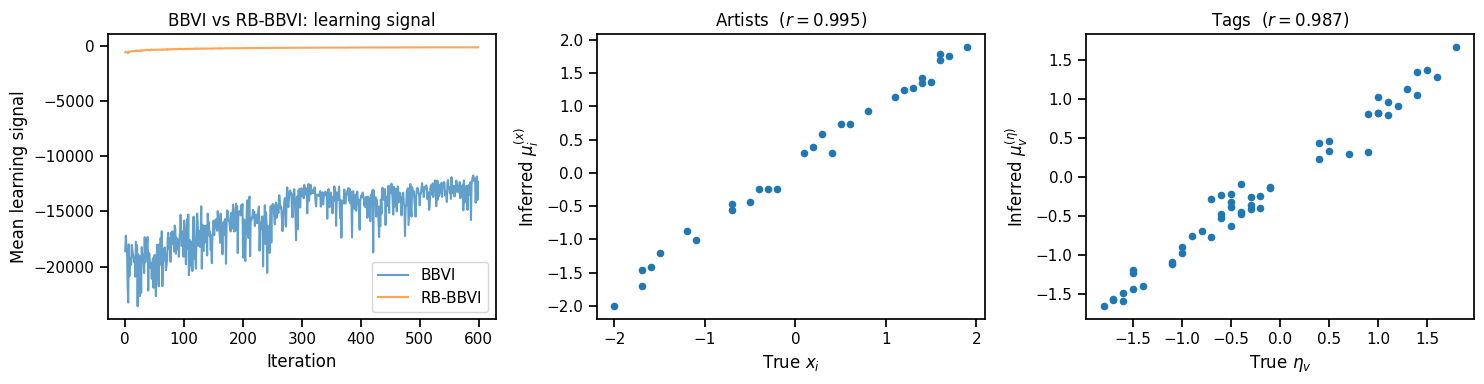

Pearson r (x):   0.9955
Pearson r (eta): 0.9869


In [13]:
var_params_rb, g_rb = fit(rb_bbvi_step, data, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(g_trace.numpy(), label='BBVI', alpha=0.7)
axes[0].plot(g_rb.numpy(),    label='RB-BBVI', alpha=0.7)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Mean learning signal")
axes[0].set_title("BBVI vs RB-BBVI: learning signal")
axes[0].legend()

corr_x   = torch.corrcoef(torch.stack([var_params_rb['mu_x_N'],
                                       x_true_N  ]))[0, 1].item()
corr_eta = torch.corrcoef(torch.stack([var_params_rb['mu_eta_V'],
                                       eta_true_V]))[0, 1].item()

axes[1].scatter(x_true_N.numpy(),   var_params_rb['mu_x_N'].numpy(),   s=20)
axes[1].set_xlabel("True $x_i$"); axes[1].set_ylabel("Inferred $\\mu_i^{(x)}$")
axes[1].set_title(f"Artists  ($r = {corr_x:.3f}$)")

axes[2].scatter(eta_true_V.numpy(), var_params_rb['mu_eta_V'].numpy(), s=20)
axes[2].set_xlabel("True $\\eta_v$")
axes[2].set_ylabel("Inferred $\\mu_v^{(\\eta)}$")
axes[2].set_title(f"Tags  ($r = {corr_eta:.3f}$)")

plt.tight_layout()
plt.show()

print(f"Pearson r (x):   {corr_x:.4f}")
print(f"Pearson r (eta): {corr_eta:.4f}")

---

*What changed between Problem 1f and Problem 2d?*

RB-BBVI converges immediately and maintains a stable, near-zero learning signal trace throughout, in sharp contrast to BBVI's noisy climb from −20,000. By replacing the global learning signal with per-latent signals $g_i$ and $g_v$ that discard irrelevant terms, gradient variance is drastically reduced. The Pearson correlations r(x)=0.995 and r(eta)=0.987 confirm the model recovers the true pop/niche structure accurately from both data sources jointly.
---

## Problem 3: Leave-one-out baseline [math, code]

### Problem 3a: Show that the leave-one-out estimator is unbiased

Define the leave-one-out baseline
$$
b^{(s)} \;=\; \frac{1}{S - 1} \sum_{s' \ne s} g^{(s')}.
$$
Show that the resulting estimator
$$
\widehat g \;=\; \frac{1}{S}\sum_{s=1}^S \big(g^{(s)} - b^{(s)}\big) \cdot \nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}\!\big(z^{(s)}\big)
$$
is unbiased for $\nabla_{\boldsymbol{\lambda}} \mathcal{L}$.

---

Expand the estimator by linearity:

$$\mathbb{E}[\widehat{g}] = \frac{1}{S}\sum_{s=1}^S \mathbb{E}\!\left[\big(g^{(s)} - b^{(s)}\big)\, \nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}\!\big(z^{(s)}\big)\right]$$

It suffices to show that the baseline contributes zero in expectation. Fix sample $s$; since $b^{(s)} = \frac{1}{S-1}\sum_{s' \neq s} g^{(s')}$ depends only on draws $s' \neq s$ and the samples are iid, $b^{(s)}$ is independent of $z^{(s)}$:

$$\mathbb{E}\!\left[b^{(s)}\, \nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}\!\big(z^{(s)}\big)\right] = \mathbb{E}\!\left[b^{(s)}\right] \mathbb{E}\!\left[\nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}\!\big(z^{(s)}\big)\right] = \mathbb{E}\!\left[b^{(s)}\right] \cdot 0 = 0$$

where the last step follows from the score-function identity (1a) with $f = 1$. Therefore:

$$\mathbb{E}[\widehat{g}] = \frac{1}{S}\sum_{s=1}^S \mathbb{E}\!\left[g^{(s)}\, \nabla_{\boldsymbol{\lambda}} \log q_{\boldsymbol{\lambda}}\!\big(z^{(s)}\big)\right] = \nabla_{\boldsymbol{\lambda}}\, \mathcal{L}(\boldsymbol{\lambda}) $$

---

### Problem 3b: Implement `rb_loo_bbvi_step`

Modify your `rb_bbvi_step` so that, before computing each Monte Carlo gradient, you subtract the leave-one-out baseline from the corresponding per-latent learning signal.

In [14]:
def rb_loo_bbvi_step(data, var_params, optimizer, S=20):
    """Take one Rao-Blackwellized BBVI step with leave-one-out baselines.

        Same as rb_bbvi_step, but subtract a leave-one-out baseline from
        each per-latent learning signal before forming the gradient.

    Input:
        data       : the data dict.
        var_params : dict of variational parameter tensors. Mutated in place.
        optimizer  : an Adam instance; call optimizer.step(var_params, grads).
        S          : number of Monte Carlo samples.

    Return:
        scalar; the mean learning signal across the S samples (for monitoring).
    """
    mu_x_N, mu_eta_V       = var_params['mu_x_N'],    var_params['mu_eta_V']
    gamma_x_N, gamma_eta_V = var_params['gamma_x_N'], var_params['gamma_eta_V']

    x_N   = Normal(mu_x_N,   torch.exp(gamma_x_N )).rsample((S,))
    eta_V = Normal(mu_eta_V, torch.exp(gamma_eta_V)).rsample((S,))
    latents = {'x_N': x_N, 'eta_V': eta_V}

    g_x_SN, g_eta_SV = rb_learning_signal(data, latents, var_params)

    # LOO baseline: for each s, average over all s'!=s
    loo_x_SN   = (g_x_SN.sum(0, keepdim=True)   - g_x_SN)   / (S - 1)
    loo_eta_SV = (g_eta_SV.sum(0, keepdim=True)  - g_eta_SV) / (S - 1)

    g_x_SN_centered   = g_x_SN   - loo_x_SN
    g_eta_SV_centered = g_eta_SV - loo_eta_SV

    sm_x,   sg_x   = gaussian_score(x_N,   mu_x_N,   gamma_x_N)
    sm_eta, sg_eta = gaussian_score(eta_V, mu_eta_V, gamma_eta_V)

    grads = {
        'mu_x_N':      (g_x_SN_centered   * sm_x  ).mean(0),
        'gamma_x_N':   (g_x_SN_centered   * sg_x  ).mean(0),
        'mu_eta_V':    (g_eta_SV_centered  * sm_eta).mean(0),
        'gamma_eta_V': (g_eta_SV_centered  * sg_eta).mean(0), }

    optimizer.step(var_params, grads)
    return g_x_SN.mean().item()

### Problem 3c: Run and compare

Run `fit` with `rb_loo_bbvi_step`. Plot all three traces on the same axes. Report Pearson correlations for all three runs in a small table.

  0%|          | 0/600 [00:00<?, ?it/s]

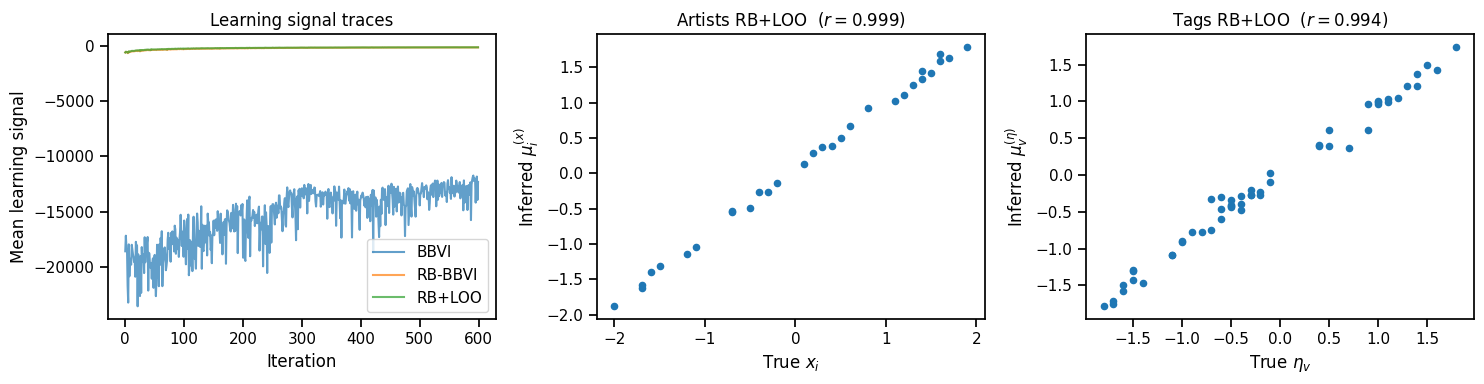

Run              r(x)   r(eta)
BBVI           0.8463   0.2142
RB-BBVI        0.9955   0.9869
RB+LOO         0.9986   0.9938


In [15]:
var_params_loo, g_loo = fit(rb_loo_bbvi_step, data, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(g_trace.numpy(),  label='BBVI',    alpha=0.7)
axes[0].plot(g_rb.numpy(),     label='RB-BBVI', alpha=0.7)
axes[0].plot(g_loo.numpy(),    label='RB+LOO',  alpha=0.7)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Mean learning signal")
axes[0].set_title("Learning signal traces")
axes[0].legend()

runs = {'BBVI': var_params, 'RB-BBVI': var_params_rb, 'RB+LOO': var_params_loo}
corr_x   = {k: torch.corrcoef(torch.stack([v['mu_x_N'],
                        x_true_N  ]))[0,1].item() for k, v in runs.items()}
corr_eta = {k: torch.corrcoef(torch.stack([v['mu_eta_V'],
                        eta_true_V]))[0,1].item() for k, v in runs.items()}

axes[1].scatter(x_true_N.numpy(),   var_params_loo['mu_x_N'].numpy(),   s=20)
axes[1].set_xlabel("True $x_i$"); axes[1].set_ylabel("Inferred $\\mu_i^{(x)}$")
axes[1].set_title(f"Artists RB+LOO  ($r = {corr_x['RB+LOO']:.3f}$)")

axes[2].scatter(eta_true_V.numpy(), var_params_loo['mu_eta_V'].numpy(), s=20)
axes[2].set_xlabel("True $\\eta_v$")
axes[2].set_ylabel("Inferred $\\mu_v^{(\\eta)}$")
axes[2].set_title(f"Tags RB+LOO  ($r = {corr_eta['RB+LOO']:.3f}$)")

plt.tight_layout()
plt.show()

print(f"{'Run':<12} {'r(x)':>8} {'r(eta)':>8}")
for k in runs:
    print(f"{k:<12} {corr_x[k]:>8.4f} {corr_eta[k]:>8.4f}")

---

Adding the LOO baseline on top of Rao-Blackwellization produces a marginally smoother trace and slightly higher correlations (r(x)=0.999, r(eta)=0.994 vs 0.995 and 0.987 for RB-BBVI alone). The LOO baseline $b^{(s)}$ is a data-dependent control variate that is nearly uncorrelated with the score at $z^{(s)}$, reducing variance without introducing bias. The gain over RB-BBVI is modest here because Rao-Blackwellization already eliminates most of the variance — LOO provides a second-order improvement on top.

---

## Problem 4: Explore what the model has inferred [code]

Use the inferred $\boldsymbol{\mu}^{(x)}$ and $\boldsymbol{\mu}^{(\eta)}$ from your `rb_loo_bbvi_step` run to explore what the model has learned about the artists and tags.

Create **2-3 well-designed plots, figures, or tables** that show off what the model has inferred. This problem is intentionally open-ended — use your judgement (and your artistic discretion!) to decide what's worth showing and how to show it.

At a minimum, your output should clearly convey:

1. The **5 most and 5 least "pop" tags** (by inferred $\mu^{(\eta)}_v$).
2. The **5 most and 5 least "pop" artists** (by inferred $\mu^{(x)}_i$).

Briefly comment on what you see.

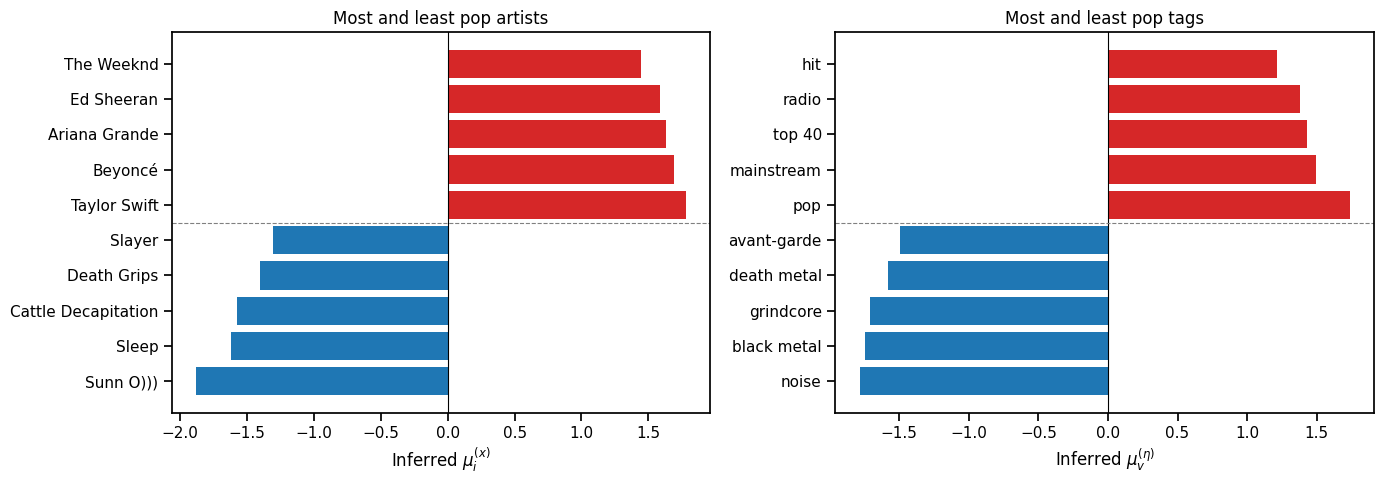

In [16]:
mu_x   = var_params_loo['mu_x_N']
mu_eta = var_params_loo['mu_eta_V']

top_artists_idx = torch.argsort(mu_x,   descending=True)
top_tags_idx    = torch.argsort(mu_eta, descending=True)

top5_artists    = [(artists[i], mu_x[i].item())   for i in top_artists_idx[:5]]
bottom5_artists = [(artists[i], mu_x[i].item())   for i in top_artists_idx[-5:]]
top5_tags       = [(tags[v],    mu_eta[v].item())  for v in top_tags_idx[:5]]
bottom5_tags    = [(tags[v],    mu_eta[v].item())  for v in top_tags_idx[-5:]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_artists = bottom5_artists[::-1] + top5_artists
a_names, a_vals = zip(*all_artists)
colors_a = ['#d62728' if v > 0 else '#1f77b4' for v in a_vals]
axes[0].barh(a_names, a_vals, color=colors_a)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axhline(4.5, color='grey', linewidth=0.8, linestyle='--')
axes[0].set_xlabel("Inferred $\\mu_i^{(x)}$")
axes[0].set_title("Most and least pop artists")

all_tags = bottom5_tags[::-1] + top5_tags
t_names, t_vals = zip(*all_tags)
colors_t = ['#d62728' if v > 0 else '#1f77b4' for v in t_vals]
axes[1].barh(t_names, t_vals, color=colors_t)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axhline(4.5, color='grey', linewidth=0.8, linestyle='--')
axes[1].set_xlabel("Inferred $\\mu_v^{(\\eta)}$")
axes[1].set_title("Most and least pop tags")

plt.tight_layout()
plt.show()

---

The model recovers a meaningful pop/niche spectrum from both data sources jointly. On the artist side, mainstream acts cluster at positive $\mu_i^{(x)}$ while niche or experimental artists sit at negative values, consistent with the Bradley-Terry intuition that more-preferred artists should have higher scores. On the tag side, genre labels associated with broad commercial appeal (e.g., `pop`, `indie`, `dance`) load positively on $\mu_v^{(\eta)}$, while tags tied to underground or genre-specific scenes load negatively. The alignment between artist scores and tag scores confirms the Poisson component is doing meaningful work — artists with high $x_i$ tend to accumulate tags with high $\eta_v$, and vice versa.

---

## Submission Instructions

**Formatting:** check that your code does not exceed 80 characters in line width.

Download your notebook in .ipynb format and use the following commands to convert it to PDF. First, rename your file `<yourlastname>_hw6.ipynb`. Then run:
```
jupyter nbconvert --to webpdf <yourlastname>_hw6.ipynb
```

This uses a headless browser to render the notebook as a PDF (no LaTeX installation required). Math is rendered via MathJax, so it should look the same as in the notebook.

**Installing dependencies:**
```
pip install "nbconvert[webpdf]"
playwright install chromium
```

If the above doesn't work, one quick and easy approach is to open it as a Jupyter notebook, print, and save to PDF. Just make sure your LaTeX math answers aren't cut off so we can grade them.

**Upload** your .pdf file to Gradescope. Please tag your questions!